## Step 1: Import Libraries
**Purpose:** Import all necessary Python libraries to perform data manipulation and visualization.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Step 2: Load the BRFSS Dataset
 **Purpose:** Load the dataset into a pandas DataFrame for analysis.

In [52]:
df = pd.read_csv("BRFSS_dataset.csv")



## Step 3: Data Cleaning and Column Renaming
 **Purpose:** Rename relevant columns for clarity and drop rows with missing values.

In [53]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
df = df.rename(columns={
    'noleisureactivitypercent': 'inactivity_percent',
    'obesitypercent': 'obesity_percent'
})
df = df.dropna(subset=['year', 'state', 'inactivity_percent', 'obesity_percent'])

## Step 4: Regional Comparison (Northeast, Southeast, Northwest, Southwest)
 **Purpose:** Compare regional averages of inactivity and obesity between 2011 and 2012 using line plots.

In [54]:
northeast = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut',
             'New York', 'New Jersey', 'Pennsylvania']

southeast = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia', 'Kentucky',
             'Tennessee', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Alabama', 'Mississippi']

southwest = ['Arizona', 'New Mexico', 'Oklahoma', 'Texas']

northwest = ['Washington', 'Oregon', 'Idaho', 'Montana', 'Wyoming', 'Alaska']

# Region assignment
def get_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in southeast:
        return 'Southeast'
    elif state in southwest:
        return 'Southwest'
    elif state in northwest:
        return 'Northwest'
    else:
        return None

df['region'] = df['state'].apply(get_region)
df = df[df['region'].notna()]
df_years = df[df['year'].isin([2011, 2012])]

# Group and aggregate
df_grouped = df_years.groupby(['region', 'year'])[['inactivity_percent', 'obesity_percent']].mean().reset_index()

## Step 5: Regional Comparison scatter plot (2011–2012)
 **Purpose:** We categorize states into regions and compare average inactivity vs. obesity rates across 2011 and 2012. We use a scatter plot with a regression line to visualize the correlation between physical inactivity and obesity across states.


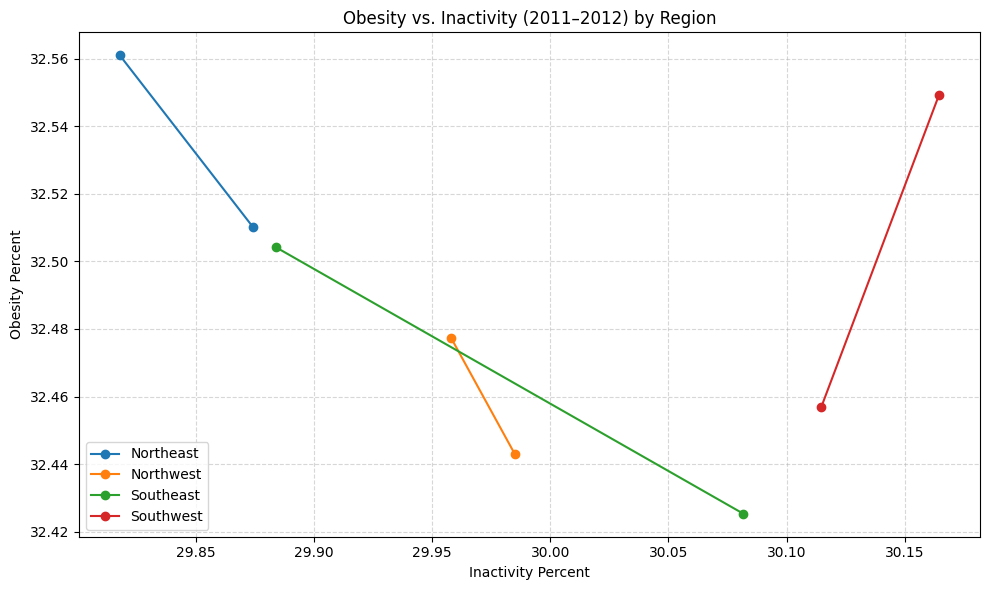

In [55]:
plt.figure(figsize=(10, 6))

for region in df_grouped['region'].unique():
    subset = df_grouped[df_grouped['region'] == region].sort_values('year')
    x_vals = subset['inactivity_percent'].values
    y_vals = subset['obesity_percent'].values
    plt.plot(x_vals, y_vals, marker='o', label=region)

plt.title("Obesity vs. Inactivity (2011–2012) by Region")
plt.xlabel("Inactivity Percent")
plt.ylabel("Obesity Percent")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



## Step 6: Summary
 **Purpose:** Summarize insights from the analysis and discuss next steps or policy implications.

- Obesity and inactivity rates show regional differences.
- There is a visible correlation between inactivity and obesity.
- Further data over more years may help understand longer-term trends.